In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/haseebekhan/healthcare-cost-dataset/Healthcare Cost Dataset/sample_submission.csv
/kaggle/input/datasets/haseebekhan/healthcare-cost-dataset/Healthcare Cost Dataset/test/test/main_df_test.csv
/kaggle/input/datasets/haseebekhan/healthcare-cost-dataset/Healthcare Cost Dataset/test/test/drg_df_test.csv
/kaggle/input/datasets/haseebekhan/healthcare-cost-dataset/Healthcare Cost Dataset/test/test/cpt_df_test.csv
/kaggle/input/datasets/haseebekhan/healthcare-cost-dataset/Healthcare Cost Dataset/test/test/icd_df_test.csv
/kaggle/input/datasets/haseebekhan/healthcare-cost-dataset/Healthcare Cost Dataset/test/test/dob_df.csv
/kaggle/input/datasets/haseebekhan/healthcare-cost-dataset/Healthcare Cost Dataset/train/train/main_df_train.csv
/kaggle/input/datasets/haseebekhan/healthcare-cost-dataset/Healthcare Cost Dataset/train/train/cpt_df_train.csv
/kaggle/input/datasets/haseebekhan/healthcare-cost-dataset/Healthcare Cost Dataset/train/train/drg_df_train.csv
/kaggle/input/dat

# **Binary Classification**

## **Preprocessing**

In [2]:
!pip install deslib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.6/172.6 kB 4.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier
from deslib.des.knora_e import KNORAE # (Stacking)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from typing import Tuple, List, Optional

import xgboost as xgb
import lightgbm as lgb
import catboost as cgb

from sklearn.metrics import accuracy_score, mean_squared_error, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import validation_curve


import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings

warnings.filterwarnings("ignore")


### **PATHS**


In [4]:
BASE_DIR = r"/kaggle/input/datasets/haseebekhan/healthcare-cost-dataset/Healthcare Cost Dataset"

TRAINING_PATH = os.path.join(BASE_DIR, "train", "train") + os.sep
TESTING_PATH  = os.path.join(BASE_DIR, "test",  "test")  + os.sep

COST_THRESHOLD = 30_000 # Cost which split it into binary label
N_FOLDS        = 5
RANDOM_STATE   = 42

In [5]:
 main_df = pd.read_csv(TRAINING_PATH + "main_df_train.csv", low_memory=False)

In [6]:
main_df.count()

Member_Key            807420
YEAR                  807420
MONTH                 807420
ProviderVisitCount    807420
ProviderCharges       807420
                       ...  
Admission             807420
AdmissionCost         807420
AdmissionLOS          807420
NEXT_YEAR_COST        807420
HighCostLabel         807420
Length: 301, dtype: int64

In [7]:
def compute_vif(df: pd.DataFrame) -> pd.DataFrame:
    """VIF for every numeric column. Constant columns are dropped first --
    a constant column gives a meaningless inf/NaN VIF that has nothing to
    do with collinearity against other features."""
    X = df.select_dtypes(include=[np.number]).copy()
    X = X.loc[:, X.nunique(dropna=False) > 1]
    X = sm.add_constant(X, has_constant="add")
    vif_df = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    })
    return vif_df[vif_df["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)


def fit_vif_drop_list(X_train: pd.DataFrame, exclude_cols=None,
                       vif_threshold: float = 10.0, max_iter: int = 200) -> list:
    """
    Iteratively drops the single worst-VIF column, recomputes, repeats --
    NOT a one-shot 'drop everything with VIF==inf', because removing one
    column changes every other column's VIF. Fit on TRAIN ONLY; apply the
    resulting list unchanged to val/test/submission via drop_multicollinear().
    """
    exclude_cols = set(exclude_cols or [])
    candidates = [c for c in X_train.select_dtypes(include=[np.number]).columns
                  if c not in exclude_cols]
    working = X_train[candidates].copy()
    dropped = []

    for _ in range(max_iter):
        nunique = working.nunique(dropna=False)
        const_cols = nunique[nunique <= 1].index.tolist()
        if const_cols:
            dropped.extend(const_cols)
            working = working.drop(columns=const_cols)
            continue

        if working.shape[1] <= 1:
            break

        vif_df = compute_vif(working)
        worst = vif_df.iloc[0]
        if worst["VIF"] <= vif_threshold:
            break

        dropped.append(worst["feature"])
        working = working.drop(columns=[worst["feature"]])

    print(f"    [VIF] dropping {len(dropped)} columns at threshold {vif_threshold}: {dropped}")
    return dropped


def drop_multicollinear(df: pd.DataFrame, drop_cols: list) -> pd.DataFrame:
    """Apply a pre-fit (train-only) drop list to any split."""
    return df.drop(columns=[c for c in drop_cols if c in df.columns])

In [8]:
"""
Corrected preprocessing pipeline.

Changes vs. the version reviewed earlier:

1. PER-ROW REFERENCE DATE (fixes the temporal-distortion issue).
   The old code used a single global `ref_date = 2023-01-01` for every row,
   regardless of which calendar YEAR that row actually belonged to. That
   means a 2020 row and a 2024 row got "days since AWV" computed against
   the same fixed anchor, which doesn't represent "as of this row's own
   prediction time" -- it silently shifts the distribution of
   DaysSinceAWV / DaysSinceLastPCP depending on a row's vintage.

   Fixed by deriving the reference date PER ROW from that row's own YEAR
   (end-of-year, Dec 31 of YEAR). This is computed identically in
   fit_main_stats() (for the sentinel) and aggregate_main() (for the
   actual gap), so train and test stay consistent and no global constant
   leaks calendar-specific information into the feature.

2. LABEL EXTRACTION BEFORE LEAKAGE-COLUMN DROP.
   NEXT_YEAR_COST / HighCostLabel must survive the pipeline to become `y`,
   but the original aggregate_main() dropped LEAKAGE_COLS (and only
   LEAKAGE_COLS) without ever pulling the label out first. Label
   construction is now an explicit, separate step that runs BEFORE
   feature cleaning, so the label is never accidentally used as a
   feature and never accidentally lost.

3. MONTH FILTER MADE EXPLICIT AND CONFIGURABLE.
   Per the competition spec, prediction rows are MONTH == -1 OR
   MONTH == 12, with the rule applied consistently across train/test.
   The hardcoded `== -1` is now a single named constant so it's easy to
   confirm/change against how the label pipeline actually defined the
   "year-end" row, instead of being silently baked into two different
   functions.

Usage:
    main_stats = fit_main_stats(main_train)
    main_tr, y_train = aggregate_main(main_train, main_stats)
    main_te, y_test  = aggregate_main(main_test,  main_stats)
"""

# ---------------------------------------------------------------------------
# Static column metadata
# ---------------------------------------------------------------------------

# Which MONTH values count as a valid "prediction row" grain.
# Per spec: MONTH = -1 (full-year rollup) OR MONTH = 12 (year-end slice).
# Pick the value(s) that match how your label pipeline actually built
# NEXT_YEAR_COST -- verify this against your ETL before trusting it blindly.
PREDICTION_ROW_MONTHS = [-1]

RAW_LABEL_COL = "NEXT_YEAR_COST"
LABEL_COL = "HighCostLabel"
HIGH_COST_THRESHOLD = 30_000

LEAKAGE_COLS = [
    "MONTH", "ActualYear", "ActualMonthNumber", "IsYTD", "QUARTER",
    "PredictedCost", "Leakage_Cost", "IsLatest",
    # add here only the ones that failed the Step 1 check, e.g.:
    # "Percentile",
]

DATE_COLS = [("AWVLastDate", "DaysSinceAWV"), ("LastPCPVisit", "DaysSinceLastPCP")]

SIMPLE_BINARY_COLS = [
    "IsCovid", "DoneBySelf", "AWV", "Admission", "Ishighrisk",
    "NonClaimBasedPayment", "AWV_Compliant_Eligible",
]

ELIGIBLE_DEPENDENT_PAIRS = [
    ("AWV_Eligible", "AWV_Compliant"),
    ("IPPE_Eligible", "IPPE_Compliant"),
]

NETWORK_PAIR = ("InNetworkPCP", "OutNetworkPCP")

DISEASE_COLS = [
    "ChronicObstructivePulmonaryDiseaseOrAsthma", "CongestiveHeartFailure",
    "BacterialPneumonia", "DiabetesShortTermComplications",
    "DiabetesLongTermComplications", "UncontrolledDiabetes",
    "AmputationDiabetes", "Dialysis", "ChronicConditions",
]

HCC_COLS = [
    "MemberHccScore", "MemberHccScoreLastYear",
    "MemberHccScoreLastTwoYear", "PersiviaMemberHccScore",
]

CAT_COLS = [
    "AWVCode", "AWVStatus", "AttributionStatus", "LastPCPProvider",
    "AWVProviderNetwork", "Payers_key", "Enrollment_key",
]

COUNT_COL_CANDIDATES = [
    "ProviderVisitCount", "ERAdmisison", "30dayHospitalReadmission", "OutpatientVisits",
    "Inpatient", "HomeHealth", "Hospice", "SkilledNursingFacilities",
    "EmergencyDepartmentVisits", "EmergencyDepartmentVisitsWithAdmissions",
    "CTEvents", "MRIEvents", "RadiologyEvents", "OtherImagingServices",
    "LabEventsPathalogy", "LabEventsClinicalDiagnostics", "PrimaryCareServicesTotal",
    "PrimaryCareServiceswithPrimaryCarePhysician", "PrimaryCareServicesWithSpecialistPhysician",
    "PrimaryCareServicesWithNursePractitioner", "30DayReadmission", "NewPatients",
    "EstablishedPatients", "PostDischargeVisits", "AmbulanceEvents", "Medication",
    "PCPVisits", "OfficeVisits", "EDVisitsWithNoFollowUp", "IPVisitsWithNoFollowUp",
    "TotalClaims", "TotalScriptsFilled", "AWVVisits", "PediatricsVisits", "UrgentCareVisit",
    "AmbulatorySurgeryVisit", "DentistEvents",
]

MISSING_FLAG_THRESHOLD = 0.01


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------

def _filter_prediction_rows(df: pd.DataFrame) -> pd.DataFrame:
    if "MONTH" in df.columns:
        return df[df["MONTH"].isin(PREDICTION_ROW_MONTHS)].reset_index(drop=True)
    return df


def _per_row_ref_date(df: pd.DataFrame) -> pd.Series:
    """End-of-year reference date derived from each row's OWN YEAR, instead
    of one global constant. Falls back to a fixed date only if YEAR is
    genuinely unavailable (shouldn't happen for prediction rows)."""
    if "YEAR" in df.columns:
        year = df["YEAR"].astype("Int64")
        # Dec 31 of that row's year
        return pd.to_datetime(year.astype(str) + "-12-31", errors="coerce")
    return pd.Series(pd.Timestamp("2023-12-31"), index=df.index)


def _extract_label(df: pd.DataFrame) -> pd.Series | None:
    """Pull HighCostLabel (or derive it from NEXT_YEAR_COST) BEFORE any
    leakage-column dropping happens, so the label is never silently lost
    or accidentally retained as a feature. Returns None if neither label
    nor raw cost column is present (e.g. true 2024 inference-only rows
    where next-year cost can't yet be known)."""
    if LABEL_COL in df.columns:
        return df[LABEL_COL].astype("Int64")
    if RAW_LABEL_COL in df.columns:
        # NaN next-year cost -> label undefined (kept as NaN, not silently 0/False)
        label = pd.Series(np.nan, index=df.index, dtype="float")
        known = df[RAW_LABEL_COL].notna()
        label.loc[known] = (df.loc[known, RAW_LABEL_COL] > HIGH_COST_THRESHOLD).astype(int)
        return label
    return None


# ---------------------------------------------------------------------------
# FIT: learn every statistic from TRAINING data only
# ---------------------------------------------------------------------------

def fit_main_stats(train_df: pd.DataFrame) -> dict:
    df = _filter_prediction_rows(train_df)

    cost_cols = [c for c in df.columns if c.endswith("_Cost") and c != "TotalCost"]
    los_cols = [c for c in df.columns if "LOS" in c]
    count_cols = [c for c in COUNT_COL_CANDIDATES if c in df.columns]

    stats = {"cost_cols": cost_cols, "los_cols": los_cols, "count_cols": count_cols}

    stats["cost_bounds"] = {}
    for c in cost_cols:
        col = df[c].dropna()
        if len(col):
            lo = min(0, col.quantile(0.001))
            hi = col.quantile(0.995)
            stats["cost_bounds"][c] = (lo, hi)
        else:
            stats["cost_bounds"][c] = (0, 0)

    stats["los_median"] = {
        c: (df.loc[df[c] > 0, c].median() if (df[c] > 0).any() else 0.0) for c in los_cols
    }

    stats["hcc_global_median"] = {}
    stats["hcc_group_median"] = {}
    for c in HCC_COLS:
        if c in df.columns:
            valid = df[c].where(df[c] >= 0)
            stats["hcc_global_median"][c] = valid.median()
            if "Ishighrisk" in df.columns:
                stats["hcc_group_median"][c] = valid.groupby(df["Ishighrisk"]).median().to_dict()

    stats["cat_freq"] = {}
    stats["cat_freq_fallback"] = {}
    for c in CAT_COLS:
        if c in df.columns:
            vc = df[c].astype(str).fillna("Unknown").value_counts(normalize=True)
            stats["cat_freq"][c] = vc.to_dict()
            stats["cat_freq_fallback"][c] = vc.min() if len(vc) else 0.0

    # --- Date sentinel: per-row reference date now, not a global constant.
    # Sentinel itself is still a single learned scalar (max observed gap
    # + 1yr) since it just needs to sit clearly past the real range.
    stats["date_sentinel"] = {}
    ref_date = _per_row_ref_date(df)
    for raw_col, new_col in DATE_COLS:
        if raw_col in df.columns:
            days = (ref_date - pd.to_datetime(df[raw_col], errors="coerce")).dt.days
            days = days.clip(lower=0)
            max_seen = days.max()
            stats["date_sentinel"][new_col] = (max_seen if pd.notna(max_seen) else 0) + 365

    stats["missing_rate"] = df.isna().mean().to_dict()
    stats["global_median"] = df.select_dtypes(include=[np.number]).median().to_dict()

    return stats


# ---------------------------------------------------------------------------
# TRANSFORM: apply stats to ANY split (train or test). Returns (X, y).
# ---------------------------------------------------------------------------

def aggregate_main(df: pd.DataFrame, stats: dict) -> tuple[pd.DataFrame, pd.Series]:
    df = _filter_prediction_rows(df).copy()

    # ---- Label extraction FIRST, before any column gets dropped ----
    y = _extract_label(df)

    drop_cols = [c for c in LEAKAGE_COLS if c in df.columns]
    drop_cols += [c for c in (RAW_LABEL_COL, LABEL_COL) if c in df.columns]
    df.drop(columns=drop_cols, inplace=True)

    # ---- Dates: per-row reference + sentinel for "never happened" ----
    ref_date = _per_row_ref_date(df)
    for raw_col, new_col in DATE_COLS:
        if raw_col in df.columns:
            parsed = pd.to_datetime(df[raw_col], errors="coerce")
            gap = (ref_date - parsed).dt.days.clip(lower=0)
            never_flag = gap.isna()
            sentinel = stats["date_sentinel"].get(new_col, 9999)
            df[new_col] = gap.fillna(sentinel)
            df[f"{new_col}_NeverRecorded"] = never_flag.astype(int)
            df.drop(columns=[raw_col], inplace=True)

    cost_cols = [c for c in stats["cost_cols"] if c in df.columns]
    los_cols = [c for c in stats["los_cols"] if c in df.columns]
    count_cols = [c for c in stats["count_cols"] if c in df.columns]

    for c in cost_cols:
        df[c] = df[c].fillna(0)
        lo, hi = stats["cost_bounds"].get(c, (0, None))
        df[c] = df[c].clip(lower=lo, upper=hi)

    for c in count_cols:
        invalid = df[c] < 0
        if invalid.any():
            df[f"{c}_HadInvalidNegative"] = invalid.astype(int)
        df[c] = df[c].fillna(0).clip(lower=0)

    for c in los_cols:
        invalid = df[c] < 0
        if invalid.any():
            df[f"{c}_WasInvalid"] = invalid.astype(int)
            df.loc[invalid, c] = stats["los_median"].get(c, 0.0)
        df[c] = df[c].fillna(0).clip(lower=0)

    for c in SIMPLE_BINARY_COLS:
        if c in df.columns:
            miss_rate = stats["missing_rate"].get(c, 0)
            if miss_rate > MISSING_FLAG_THRESHOLD:
                df[f"{c}_WasMissing"] = df[c].isna().astype(int)
            df[c] = df[c].fillna(0).replace({True: 1, False: 0}).astype(int)

    for elig_col, dep_col in ELIGIBLE_DEPENDENT_PAIRS:
        if elig_col in df.columns and dep_col in df.columns:
            elig = df[elig_col].fillna(0).replace({True: 1, False: 0}).astype(int)
            dep_missing_while_eligible = (elig == 1) & df[dep_col].isna()
            df[f"{dep_col}_MissingWhileEligible"] = dep_missing_while_eligible.astype(int)
            dep = df[dep_col].fillna(0).replace({True: 1, False: 0}).astype(int)
            dep = np.where(elig == 0, 0, dep)
            df[elig_col] = elig
            df[dep_col] = dep

    in_col, out_col = NETWORK_PAIR
    if in_col in df.columns and out_col in df.columns:
        no_pcp = df[in_col].isna() & df[out_col].isna()
        df["NoPCPOnRecord"] = no_pcp.astype(int)
        df[in_col] = df[in_col].fillna(0).astype(int)
        df[out_col] = df[out_col].fillna(0).astype(int)

    for c in DISEASE_COLS:
        if c in df.columns:
            df[c] = (df[c].fillna(0).astype(int)
                     if df[c].dropna().isin([0, 1, True, False]).all()
                     else df[c].fillna(0))

    for c in HCC_COLS:
        if c in df.columns:
            df[f"{c}_WasMissing"] = df[c].isna().astype(int)
            df[c] = df[c].where(df[c] >= 0)
            if "Ishighrisk" in df.columns and c in stats.get("hcc_group_median", {}):
                group_map = stats["hcc_group_median"][c]
                fallback = stats["hcc_global_median"].get(c, 0.0)
                df[c] = df[c].fillna(df["Ishighrisk"].map(group_map)).fillna(fallback)
            else:
                df[c] = df[c].fillna(stats["hcc_global_median"].get(c, 0.0))

    for c in CAT_COLS:
        if c in df.columns:
            freq_map = stats["cat_freq"].get(c, {})
            fallback = stats["cat_freq_fallback"].get(c, 0.0)
            df[c] = df[c].astype(str).fillna("Unknown").map(freq_map).fillna(fallback)

    num_cols = df.select_dtypes(include=[np.number]).columns
    leftover_na = df[num_cols].isna().sum()
    leftover_cols = leftover_na[leftover_na > 0].index.tolist()
    if leftover_cols:
        print(f"    [aggregate_main] filling leftover NaNs with train median for: {leftover_cols}")
        for c in leftover_cols:
            df[c] = df[c].fillna(stats["global_median"].get(c, 0.0))

    print(f"    main_df → {df.shape[0]:,} rows × {df.shape[1]} cols")
    return df, y


def _to_year(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return series.astype("Int64")
    return pd.to_datetime(series, errors="coerce").dt.year


# ═══════════════════════════════════════════════════════════════════════════
#  dob_df
# ═══════════════════════════════════════════════════════════════════════════
def fit_dob_stats(dob_train: pd.DataFrame) -> dict:
    dob = dob_train.copy()
    birth_year = pd.to_datetime(dob["DOB_Key"], errors="coerce").dt.year
    return {
        "birth_year_median": birth_year.median(),
        "gender_mode": dob["Gender_Key"].mode().iloc[0] if dob["Gender_Key"].notna().any() else 0,
        "agegroup_mode": dob["AgeGroup_Key"].mode().iloc[0] if dob["AgeGroup_Key"].notna().any() else 0,
    }


def aggregate_dob(dob: pd.DataFrame, stats: dict) -> pd.DataFrame:
    dob = dob.copy()
    dob["BirthYear"] = pd.to_datetime(dob["DOB_Key"], errors="coerce").dt.year
    dob["BirthYear"] = dob["BirthYear"].fillna(stats["birth_year_median"])
    dob["Gender_Key"] = dob["Gender_Key"].fillna(stats["gender_mode"]).astype(int)
    dob["AgeGroup_Key"] = dob["AgeGroup_Key"].fillna(stats["agegroup_mode"]).astype(int)
    dob.drop(columns=["DOB_Key"], inplace=True)
    print(f"    dob_df  → {dob.shape[0]:,} rows × {dob.shape[1]} cols")
    return dob


# ═══════════════════════════════════════════════════════════════════════════
#  cpt_df
# ═══════════════════════════════════════════════════════════════════════════
def fit_cpt_stats(cpt_train: pd.DataFrame) -> dict:
    cpt = cpt_train.copy()
    cpt["Procedure_Code"] = cpt["Procedure_Code"].fillna("Unknown").astype(str)
    cpt["YEAR"] = _to_year(cpt["StartDate"])
    top_per_group = cpt.groupby(["Member_Key", "YEAR"])["Procedure_Code"].agg(
        lambda x: x.mode().iloc[0] if len(x) else "Unknown")
    freq = top_per_group.value_counts(normalize=True)
    return {"top_proc_freq": freq.to_dict(), "top_proc_fallback": freq.min() if len(freq) else 0.0}


def aggregate_cpt(cpt: pd.DataFrame, stats: dict) -> pd.DataFrame:
    cpt = cpt.copy()
    cpt["Procedure_Code"] = cpt["Procedure_Code"].fillna("Unknown").astype(str)
    cpt["YEAR"] = _to_year(cpt["StartDate"])

    agg = cpt.groupby(["Member_Key", "YEAR"])["Procedure_Code"].agg(
        cpt_ProcedureCount="count",
        cpt_UniqueProcedures="nunique",
        cpt_TopProcedure=lambda x: x.mode().iloc[0] if len(x) else "Unknown",
    ).reset_index()

    agg["cpt_ProcedureDiversity"] = agg["cpt_UniqueProcedures"] / agg["cpt_ProcedureCount"]
    agg["cpt_TopProcedure"] = agg["cpt_TopProcedure"].map(stats["top_proc_freq"]).fillna(stats["top_proc_fallback"])

    print(f"    cpt_df  → {agg.shape[0]:,} rows after aggregation")
    return agg


# ═══════════════════════════════════════════════════════════════════════════
#  drg_df
# ═══════════════════════════════════════════════════════════════════════════
def fit_drg_stats(drg_train: pd.DataFrame) -> dict:
    drg = drg_train.copy()
    drg["Code"] = drg["Code"].fillna("Unknown").astype(str)

    code_freq = drg["Code"].value_counts()
    rare_codes = set(code_freq[code_freq == 1].index)

    drg["YEAR"] = _to_year(drg["Start_Date_Year"])
    most_common_per_group = drg.groupby(["Member_Key", "YEAR"])["Code"].agg(
        lambda x: x.mode().iloc[0] if len(x) else "Unknown")
    mc_freq = most_common_per_group.value_counts(normalize=True)

    return {
        "rare_codes": rare_codes,
        "mostcommon_freq": mc_freq.to_dict(),
        "mostcommon_fallback": mc_freq.min() if len(mc_freq) else 0.0,
    }


def aggregate_drg(drg: pd.DataFrame, stats: dict) -> pd.DataFrame:
    drg = drg.copy()
    drg["Code"] = drg["Code"].fillna("Unknown").astype(str)
    drg["YEAR"] = _to_year(drg["Start_Date_Year"])

    agg = drg.groupby(["Member_Key", "YEAR"])["Code"].agg(
        drg_ClaimsCount="count",
        drg_UniqueDRGs="nunique",
        drg_MostCommon=lambda x: x.mode().iloc[0] if len(x) else "Unknown",
    ).reset_index()

    drg["is_rare"] = drg["Code"].isin(stats["rare_codes"]).astype(int)
    rare_agg = drg.groupby(["Member_Key", "YEAR"])["is_rare"].sum().reset_index()
    rare_agg.rename(columns={"is_rare": "drg_RareDRGCount"}, inplace=True)
    agg = agg.merge(rare_agg, on=["Member_Key", "YEAR"], how="left")

    agg["drg_MostCommon"] = agg["drg_MostCommon"].map(stats["mostcommon_freq"]).fillna(stats["mostcommon_fallback"])

    print(f"    drg_df  → {agg.shape[0]:,} rows after aggregation")
    return agg


# ═══════════════════════════════════════════════════════════════════════════
#  icd_df
# ═══════════════════════════════════════════════════════════════════════════
def fit_icd_stats(icd_train: pd.DataFrame) -> dict:
    icd = icd_train.copy()
    icd["Diagnosis_Code"] = icd["Diagnosis_Code"].fillna("Unknown").astype(str).str.upper().str.strip()
    icd["YEAR"] = _to_year(icd["Start_Date"])

    icd["ICD_Prefix"] = icd["Diagnosis_Code"].str[:3]
    top_prefixes = icd["ICD_Prefix"].value_counts().head(11).index.tolist()
    chronic_tuple = tuple(top_prefixes)

    top_per_group = (
        icd.groupby(["Member_Key", "YEAR"])["Diagnosis_Code"]
        .value_counts()
        .groupby(level=[0, 1])
        .idxmax()
        .apply(lambda x: x[2])
    )
    freq = top_per_group.value_counts(normalize=True)

    return {
        "top_icd_freq": freq.to_dict(),
        "top_icd_fallback": freq.min() if len(freq) else 0.0,
        "chronic_prefixes": chronic_tuple,
    }


def aggregate_icd(icd: pd.DataFrame, stats: dict) -> pd.DataFrame:
    icd = icd.copy()
    icd["Diagnosis_Code"] = icd["Diagnosis_Code"].fillna("Unknown").astype(str).str.upper().str.strip()
    target_prefixes = stats.get("chronic_prefixes", ())
    icd["is_chronic"] = icd["Diagnosis_Code"].str.startswith(target_prefixes).astype(int)
    icd["YEAR"] = _to_year(icd["Start_Date"])

    agg = icd.groupby(["Member_Key", "YEAR"]).agg(
        icd_DiagnosisCount=("Diagnosis_Code", "count"),
        icd_UniqueDiagnoses=("Diagnosis_Code", "nunique"),
        icd_ChronicDiagnosisCount=("is_chronic", "sum"),
    )

    top_icd = (
        icd.groupby(["Member_Key", "YEAR"])["Diagnosis_Code"]
        .value_counts()
        .groupby(level=[0, 1])
        .idxmax()
        .apply(lambda x: x[2])
    )
    agg["icd_TopICD"] = top_icd
    agg = agg.reset_index()

    agg["icd_ICDDiversity"] = agg["icd_UniqueDiagnoses"] / agg["icd_DiagnosisCount"]
    agg["icd_TopICD"] = agg["icd_TopICD"].map(stats["top_icd_freq"]).fillna(stats["top_icd_fallback"])

    print(f"    icd_df  → {agg.shape[0]:,} rows after aggregation")
    return agg


# ═══════════════════════════════════════════════════════════════════════════
#  MERGE
# ═══════════════════════════════════════════════════════════════════════════
def build_feature_table(main: pd.DataFrame, dob: pd.DataFrame, cpt: pd.DataFrame,
                         drg: pd.DataFrame, icd: pd.DataFrame,
                         min_age: int = 0, max_age: int = 110) -> pd.DataFrame:
    main, dob, cpt, drg, icd = main.copy(), dob.copy(), cpt.copy(), drg.copy(), icd.copy()

    for df in [main, dob, cpt, drg, icd]:
        df["Member_Key"] = df["Member_Key"].astype(int)
    for df in [main, cpt, drg, icd]:
        if "YEAR" in df.columns:
            df["YEAR"] = df["YEAR"].astype(int)

    merged = main.merge(dob, on="Member_Key", how="left")
    merged = merged.merge(cpt, on=["Member_Key", "YEAR"], how="left")
    merged = merged.merge(drg, on=["Member_Key", "YEAR"], how="left")
    merged = merged.merge(icd, on=["Member_Key", "YEAR"], how="left")

    if "BirthYear" in merged.columns and "YEAR" in merged.columns:
        merged["Age"] = (merged["YEAR"] - merged["BirthYear"]).clip(lower=min_age, upper=max_age)
        merged.drop(columns=["BirthYear"], inplace=True)

    agg_fill = [c for c in merged.columns if c.startswith(("cpt_", "drg_", "icd_"))]
    merged[agg_fill] = merged[agg_fill].fillna(0)

    print(f"    merged  → {merged.shape[0]:,} rows × {merged.shape[1]} cols")
    return merged



In [9]:

# ─────────────────────────────────────────────────────────────────────────────
#  End-to-end usage
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    BASE_DIR = r"/kaggle/input/datasets/haseebekhan/healthcare-cost-dataset/Healthcare Cost Dataset"
    TRAINING_PATH = os.path.join(BASE_DIR, "train", "train") + os.sep
    TESTING_PATH = os.path.join(BASE_DIR, "test", "test") + os.sep

    # ── Load raw tables ───────────────────────────────────────────────────
    main_train = pd.read_csv(TRAINING_PATH + "main_df_train.csv")
    
    # ── Leakage audit: check suspicious columns against NEXT_YEAR_COST ──
    suspicious_cols = ["Diagnosis", "Percentile", "PMPMCost", "TotalCost", "OONPreferredCost"]
    
    for c in suspicious_cols:
        if c in main_df.columns:
            corr = main_df[[c, "NEXT_YEAR_COST"]].corr().iloc[0, 1]
            print(f"{c:20s} corr with NEXT_YEAR_COST: {corr:.3f}")
            
    main_test = pd.read_csv(TESTING_PATH + "main_df_test.csv")
    dob_train = pd.read_csv(TRAINING_PATH + "dob_df.csv")
    dob_test = pd.read_csv(TESTING_PATH + "dob_df.csv")
    cpt_train = pd.read_csv(TRAINING_PATH + "cpt_df_train.csv")
    cpt_test = pd.read_csv(TESTING_PATH + "cpt_df_test.csv")
    drg_train = pd.read_csv(TRAINING_PATH + "drg_df_train.csv")
    drg_test = pd.read_csv(TESTING_PATH + "drg_df_test.csv")
    icd_train = pd.read_csv(TRAINING_PATH + "icd_df_train.csv")
    icd_test = pd.read_csv(TESTING_PATH + "icd_df_test.csv")

    # ── Fit stats on TRAIN ONLY ────────────────────────────────────────────
    main_stats = fit_main_stats(main_train)
    dob_stats = fit_dob_stats(dob_train)
    cpt_stats = fit_cpt_stats(cpt_train)
    drg_stats = fit_drg_stats(drg_train)
    icd_stats = fit_icd_stats(icd_train)

    # ── Aggregate (apply stats to BOTH splits); labels come out separately ─
    main_tr, y_train_full = aggregate_main(main_train, main_stats)
    main_te, y_test_full = aggregate_main(main_test, main_stats)

    dob_tr = aggregate_dob(dob_train, dob_stats)
    dob_te = aggregate_dob(dob_test, dob_stats)
    cpt_tr = aggregate_cpt(cpt_train, cpt_stats)
    cpt_te = aggregate_cpt(cpt_test, cpt_stats)
    drg_tr = aggregate_drg(drg_train, drg_stats)
    drg_te = aggregate_drg(drg_test, drg_stats)
    icd_tr = aggregate_icd(icd_train, icd_stats)
    icd_te = aggregate_icd(icd_test, icd_stats)

    # ── Build feature tables ───────────────────────────────────────────────
    features_train = build_feature_table(main_tr, dob_tr, cpt_tr, drg_tr, icd_tr)
    features_test = build_feature_table(main_te, dob_te, cpt_te, drg_te, icd_te)

    # ── Reattach labels (index-aligned to the pre-merge main_tr/main_te) ──
    # build_feature_table preserves row order/count of `main`, so positional
    # alignment with y_train_full/y_test_full (which came from the same
    # main_tr/main_te before merging) is safe here.
    features_train[LABEL_COL] = y_train_full.values
    features_test[LABEL_COL] = y_test_full.values if y_test_full is not None else np.nan
    
    # ── Final supervised train set ─────────────────────────────────────────
    id_cols = ["Member_Key", "YEAR"]

    train_labeled = features_train.dropna(subset=[LABEL_COL]).reset_index(drop=True)
    X_train_full = train_labeled.drop(columns=[LABEL_COL] + [c for c in id_cols if c in train_labeled.columns])
    y_train_full_clean = train_labeled[LABEL_COL].astype(int)
    member_key_full = train_labeled["Member_Key"]

    test_labeled = features_test.dropna(subset=[LABEL_COL])
    if len(test_labeled):
        test_labeled = test_labeled.reset_index(drop=True)
        X_test = test_labeled.drop(columns=[LABEL_COL] + [c for c in id_cols if c in test_labeled.columns])
        y_test = test_labeled[LABEL_COL].astype(int)
    else:
        print("    [warn] No labels available in test split (2024) -- "
              "y_test is undefined; X_test is for inference only.")
        X_test = features_test.drop(columns=[LABEL_COL] + [c for c in id_cols if c in features_test.columns])
        y_test = None

    # ── STEP 2: Fit VIF drop-list on TRAIN ONLY, apply to train + test ─────
    # (No X_train/X_val split needed for this -- VIF is computed on the full
    # labeled training pool, X_train_full, before any CV split happens.)
    vif_drop_cols = fit_vif_drop_list(
        X_train_full,
        exclude_cols=["Member_Key", "YEAR"],   # not present here, but harmless if listed
        vif_threshold=10.0,
    )

    X_train_full = drop_multicollinear(X_train_full, vif_drop_cols)
    X_test       = drop_multicollinear(X_test, vif_drop_cols)

    print(f"\n[VIF] X_train_full after drop: {X_train_full.shape}")
    print(f"[VIF] X_test after drop:       {X_test.shape}")

    # ── Train/val split -- now happens AFTER the VIF-cleaned columns exist ─
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full_clean,
        test_size=0.2, stratify=y_train_full_clean, random_state=42,
    )
    
    member_groups = member_key_full.loc[X_train.index]
    print(f"\nX_train: {X_train.shape}   y_train positive rate: {y_train.mean():.3f}")
    print(f"X_val:   {X_val.shape}   y_val positive rate:   {y_val.mean():.3f}")
    print(f"X_test:  {X_test.shape}" + (f"   y_test positive rate: {y_test.mean():.3f}" if y_test is not None else "  (y_test unavailable)"))
    print(member_groups.shape, X_train.shape)    

Diagnosis            corr with NEXT_YEAR_COST: 0.192
Percentile           corr with NEXT_YEAR_COST: 0.043
PMPMCost             corr with NEXT_YEAR_COST: 0.210
TotalCost            corr with NEXT_YEAR_COST: 0.208
OONPreferredCost     corr with NEXT_YEAR_COST: -0.010
    [aggregate_main] filling leftover NaNs with train median for: ['PersiviaMemberHccScore', 'PersiviaCost']
    main_df → 45,394 rows × 301 cols
    [aggregate_main] filling leftover NaNs with train median for: ['PersiviaMemberHccScore']
    main_df → 12,387 rows × 301 cols
    dob_df  → 64,443 rows × 4 cols
    dob_df  → 64,443 rows × 4 cols
    cpt_df  → 162,526 rows after aggregation
    cpt_df  → 41,010 rows after aggregation
    drg_df  → 230,814 rows after aggregation
    drg_df  → 38,295 rows after aggregation
    icd_df  → 162,525 rows after aggregation
    icd_df  → 41,002 rows after aggregation
    merged  → 45,394 rows × 317 cols
    merged  → 12,387 rows × 317 cols
    [warn] No labels available in test split (2

In [10]:
# X_train_full.to_csv("/kaggle/working/X_train_full.csv", index=False)
# y_train_full_clean.to_csv("/kaggle/working/y_train_full_clean.csv", index=False)

# X_train_full, y_train_full_clean,

# print("Files saved successfully!")

In [11]:
# ── Fit VIF drop-list on TRAIN ONLY, apply to all splits ──
vif_drop_cols = fit_vif_drop_list(
    X_train_full,
    exclude_cols=["Member_Key", "YEAR"],   # already excluded in your X_train_full, kept safe
    vif_threshold=10.0,
)

X_train_full = drop_multicollinear(X_train_full, vif_drop_cols)
X_test       = drop_multicollinear(X_test, vif_drop_cols)

    [VIF] dropping 0 columns at threshold 10.0: []


In [12]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold


In [13]:
def objective(trial):

    params = {

        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",

        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.03, log=True
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves", 31, 127
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 6, 10
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples", 40, 150
        ),

        "feature_fraction": trial.suggest_float(
            "feature_fraction", 0.70, 0.95
        ),

        "bagging_fraction": trial.suggest_float(
            "bagging_fraction", 0.70, 0.95
        ),

        "bagging_freq": trial.suggest_int(
            "bagging_freq", 3, 7
        ),

        "lambda_l1": trial.suggest_float(
            "lambda_l1", 0.0, 3.0
        ),

        "lambda_l2": trial.suggest_float(
            "lambda_l2", 0.0, 5.0
        ),

        "min_split_gain": trial.suggest_float(
            "min_split_gain", 0.0, 0.05
        ),

        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight", 3.0, 10.0
        ),
        
        "is_unbalance": False,
        "verbosity": -1,
        "seed": 42,
        "n_jobs": -1
    }

    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_scores = []

    for train_idx, valid_idx in cv.split(X_train, y_train, groups=member_groups):

        X_tr = X_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]

        X_va = X_train.iloc[valid_idx]
        y_va = y_train.iloc[valid_idx]

        model = lgb.LGBMClassifier(
            **params,
            n_estimators=5000
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            callbacks=[
                lgb.early_stopping(
                    200,
                    verbose=False
                )
            ]
        )

        prob = model.predict_proba(X_va)[:, 1]

        best_f1 = 0

        for threshold in np.arange(0.10, 0.71, 0.01):

            pred = (prob >= threshold).astype(int)

            score = f1_score(y_va, pred)

            if score > best_f1:
                best_f1 = score

        fold_scores.append(best_f1)

    return np.mean(fold_scores)

In [14]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=200,
    show_progress_bar=True
)

[I 2026-07-01 16:19:14,843] A new study created in memory with name: no-name-53ed693a-d5e5-46f1-be5a-e8fd94f86acb


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-07-01 16:19:54,088] Trial 0 finished with value: 0.4461316127704727 and parameters: {'learning_rate': 0.015090410414033417, 'num_leaves': 123, 'max_depth': 9, 'min_child_samples': 106, 'feature_fraction': 0.7390046601106091, 'bagging_fraction': 0.7389986300840506, 'bagging_freq': 3, 'lambda_l1': 2.5985284373248057, 'lambda_l2': 3.005575058716044, 'min_split_gain': 0.03540362888980227, 'scale_pos_weight': 3.144091460070617}. Best is trial 0 with value: 0.4461316127704727.
[I 2026-07-01 16:20:24,461] Trial 1 finished with value: 0.4432977584667096 and parameters: {'learning_rate': 0.0290244905546386, 'num_leaves': 111, 'max_depth': 7, 'min_child_samples': 60, 'feature_fraction': 0.7458511274633584, 'bagging_fraction': 0.7760605607398844, 'bagging_freq': 5, 'lambda_l1': 1.2958350559263474, 'lambda_l2': 1.4561457009902097, 'min_split_gain': 0.030592644736118974, 'scale_pos_weight': 3.9764570245642927}. Best is trial 0 with value: 0.4461316127704727.
[I 2026-07-01 16:21:04,771] Tria

In [15]:
print("=" * 60)
print("Best Mean CV F1:", study.best_value)
print("=" * 60)

for k, v in study.best_params.items():
    print(f"{k}: {v}")

Best Mean CV F1: 0.44986650778514364
learning_rate: 0.01256843026056675
num_leaves: 85
max_depth: 6
min_child_samples: 100
feature_fraction: 0.7823119904363387
bagging_fraction: 0.8176960345566354
bagging_freq: 6
lambda_l1: 1.7128302352353322
lambda_l2: 2.474128404073894
min_split_gain: 0.009021460015645922
scale_pos_weight: 3.42855642104554


In [16]:
params = study.best_params.copy()

params.update({
    "objective": "binary",
    "metric": "auc",
    "verbosity": -1,
    "seed": 42
})

final_model = lgb.LGBMClassifier(
    **params,
    n_estimators=5000
)

final_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(200)
    ]
)

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[570]	valid_0's auc: 0.802599


LGBMClassifier(bagging_fraction=0.8176960345566354, bagging_freq=6,
               feature_fraction=0.7823119904363387,
               lambda_l1=1.7128302352353322, lambda_l2=2.474128404073894,
               learning_rate=0.01256843026056675, max_depth=6, metric='auc',
               min_child_samples=100, min_split_gain=0.009021460015645922,
               n_estimators=5000, num_leaves=85, objective='binary',
               scale_pos_weight=3.42855642104554, seed=42, verbosity=-1)

In [17]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.02,
    max_depth=6,
    scale_pos_weight=study.best_params["scale_pos_weight"],
    eval_metric="auc",
    random_state=42,
    early_stopping_rounds=100,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

lgb_prob = final_model.predict_proba(X_val)[:, 1]
xgb_prob = xgb_model.predict_proba(X_val)[:, 1]
ensemble_prob = (lgb_prob + xgb_prob) / 2

best_threshold_ens = 0.50
best_f1_ens = 0
for threshold in np.arange(0.10, 0.91, 0.01):
    pred = (ensemble_prob >= threshold).astype(int)
    score = f1_score(y_val, pred)
    if score > best_f1_ens:
        best_f1_ens = score
        best_threshold_ens = threshold

print(f"Ensemble Best Threshold : {best_threshold_ens:.2f}")
print(f"Ensemble Best F1        : {best_f1_ens:.4f}")

Ensemble Best Threshold : 0.51
Ensemble Best F1        : 0.4454


In [18]:
import numpy as np

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score
)

# Predict probabilities
y_prob = final_model.predict_proba(X_val)[:, 1]

best_threshold = 0.50
best_f1 = 0

for threshold in np.arange(0.10, 0.91, 0.01):

    y_pred = (y_prob >= threshold).astype(int)

    score = f1_score(y_val, y_pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Best F1 Score  : {best_f1:.4f}")

Best Threshold : 0.48
Best F1 Score  : 0.4510


In [19]:
y_pred = (y_prob >= best_threshold).astype(int)

In [20]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      8050
           1       0.42      0.48      0.45      1029

    accuracy                           0.87      9079
   macro avg       0.68      0.70      0.69      9079
weighted avg       0.87      0.87      0.87      9079



In [21]:
cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[7372  678]
 [ 532  497]]


In [22]:
print(f"F1 Score      : {f1_score(y_val, y_pred):.4f}")
print(f"Precision     : {precision_score(y_val, y_pred):.4f}")
print(f"Recall        : {recall_score(y_val, y_pred):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_val, y_prob):.4f}")
print(f"PR-AUC        : {average_precision_score(y_val, y_prob):.4f}")

F1 Score      : 0.4510
Precision     : 0.4230
Recall        : 0.4830
ROC-AUC       : 0.8026
PR-AUC        : 0.4531


In [23]:
print("=" * 50)
print("Validation Performance")
print("=" * 50)

print(f"Threshold : {best_threshold:.2f}")
print(f"F1 Score  : {f1_score(y_val, y_pred):.4f}")
print(f"Precision : {precision_score(y_val, y_pred):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_val, y_prob):.4f}")
print(f"PR AUC    : {average_precision_score(y_val, y_prob):.4f}")

print("\nClassification Report")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_val, y_pred))

Validation Performance
Threshold : 0.48
F1 Score  : 0.4510
Precision : 0.4230
Recall    : 0.4830
ROC AUC   : 0.8026
PR AUC    : 0.4531

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      8050
           1       0.42      0.48      0.45      1029

    accuracy                           0.87      9079
   macro avg       0.68      0.70      0.69      9079
weighted avg       0.87      0.87      0.87      9079


Confusion Matrix
[[7372  678]
 [ 532  497]]


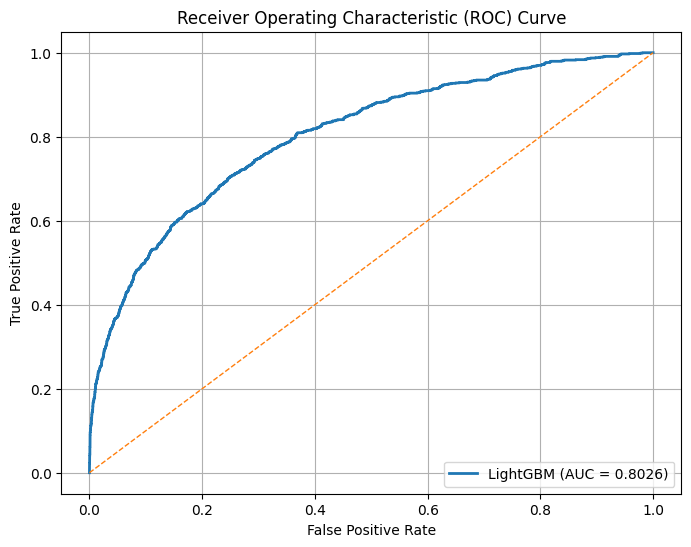

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Probability predictions
y_prob = final_model.predict_proba(X_val)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2, label=f"LightGBM (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle='--', linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

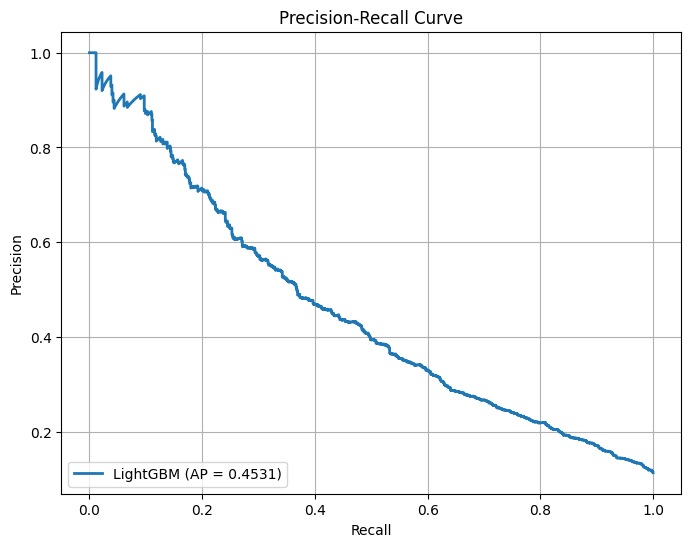

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_val, y_prob)
ap = average_precision_score(y_val, y_prob)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, linewidth=2,
         label=f"LightGBM (AP = {ap:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True)

plt.show()

In [26]:
print(features_train.columns.tolist())

['Member_Key', 'YEAR', 'ProviderVisitCount', 'ProviderCharges', 'TotalCost', 'MemberHccScore', 'MemberHccScoreLastYear', 'MemberHccScoreLastTwoYear', 'ERAdmisison', '30dayHospitalReadmission', 'OutpatientVisits', 'Inpatient', 'HomeHealth', 'Hospice', 'SkilledNursingFacilities', 'EmergencyDepartmentVisits', 'EmergencyDepartmentVisitsWithAdmissions', 'CTEvents', 'MRIEvents', 'RadiologyEvents', 'OtherImagingServices', 'LabEventsPathalogy', 'LabEventsClinicalDiagnostics', 'ChronicObstructivePulmonaryDiseaseOrAsthma', 'CongestiveHeartFailure', 'BacterialPneumonia', 'DiabetesShortTermComplications', 'DiabetesLongTermComplications', 'UncontrolledDiabetes', 'AmputationDiabetes', 'PrimaryCareServicesTotal', 'PrimaryCareServiceswithPrimaryCarePhysician', 'PrimaryCareServicesWithSpecialistPhysician', 'PrimaryCareServicesWithNursePractitioner', '30DayReadmission', 'NewPatients', 'EstablishedPatients', 'PostDischargeVisits', 'AmbulanceEvents', 'Medication', 'ERAdmisison_Cost', '30dayHospitalReadmis

In [27]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select only numeric columns
numeric_df = X_train.select_dtypes(include=['number']).copy()

# 2. Replace infinity values (inf and -inf) with NaN
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. Drop columns that are completely empty/NaN (mean calculation would fail on these)
numeric_df.dropna(axis=1, how='all', inplace=True)

# 4. Fill remaining NaNs with the column mean
numeric_df = numeric_df.fillna(numeric_df.mean())

# 5. Quick safety check: Drop columns with zero variance (all identical values)
# Because an entirely constant column will cause perfect collinearity issues
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

# 6. Add the constant intercept for VIF
numeric_df['intercept'] = 1

# 7. Calculate VIF safely
vif_data = pd.DataFrame()
vif_data["feature"] = [col for col in numeric_df.columns if col != 'intercept']
vif_data["VIF"] = [
    variance_inflation_factor(numeric_df.values, i) 
    for i in range(len(numeric_df.columns)) 
    if numeric_df.columns[i] != 'intercept'
]

print(vif_data.sort_values(by="VIF", ascending=False))

                                     feature        VIF
56                              DialysisCost  11.251254
76                             PartBDialysis   9.387202
97            SwingBedSNFOutNetworkEncounter   9.357390
141                      icd_UniqueDiagnoses   9.356316
138                          drg_ClaimsCount   9.111850
..                                       ...        ...
105             RHCOutpatientOutNetwork_Cost   1.085722
4    EmergencyDepartmentVisitsWithAdmissions   1.045556
40            PsychiatricHospitalorUnit_Cost   1.038850
140                         drg_RareDRGCount   1.008628
132                         DaysSinceLastPCP   1.006551

[146 rows x 2 columns]


In [28]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(vif_data.sort_values(by="VIF", ascending=False))

                                               feature        VIF
56                                        DialysisCost  11.251254
76                                       PartBDialysis   9.387202
97                      SwingBedSNFOutNetworkEncounter   9.357390
141                                icd_UniqueDiagnoses   9.356316
138                                    drg_ClaimsCount   9.111850
92                          SwingBedSNFOutNetworkSpend   8.439852
36                              IPVisitsWithNoFollowUp   7.890082
130                                      AdmissionCost   7.783881
64         30DaysReadmissionShortTermStayHospital_Cost   7.760746
50                                   SwingBedSNF_Visit   7.696683
75                                                 DME   7.546740
102                                 OutNetworkPCP_Cost   7.426909
51                       EvaluationAndManagement_Visit   7.403108
59                     RehabilitationHospitalorUnitLOS   7.321339
38        

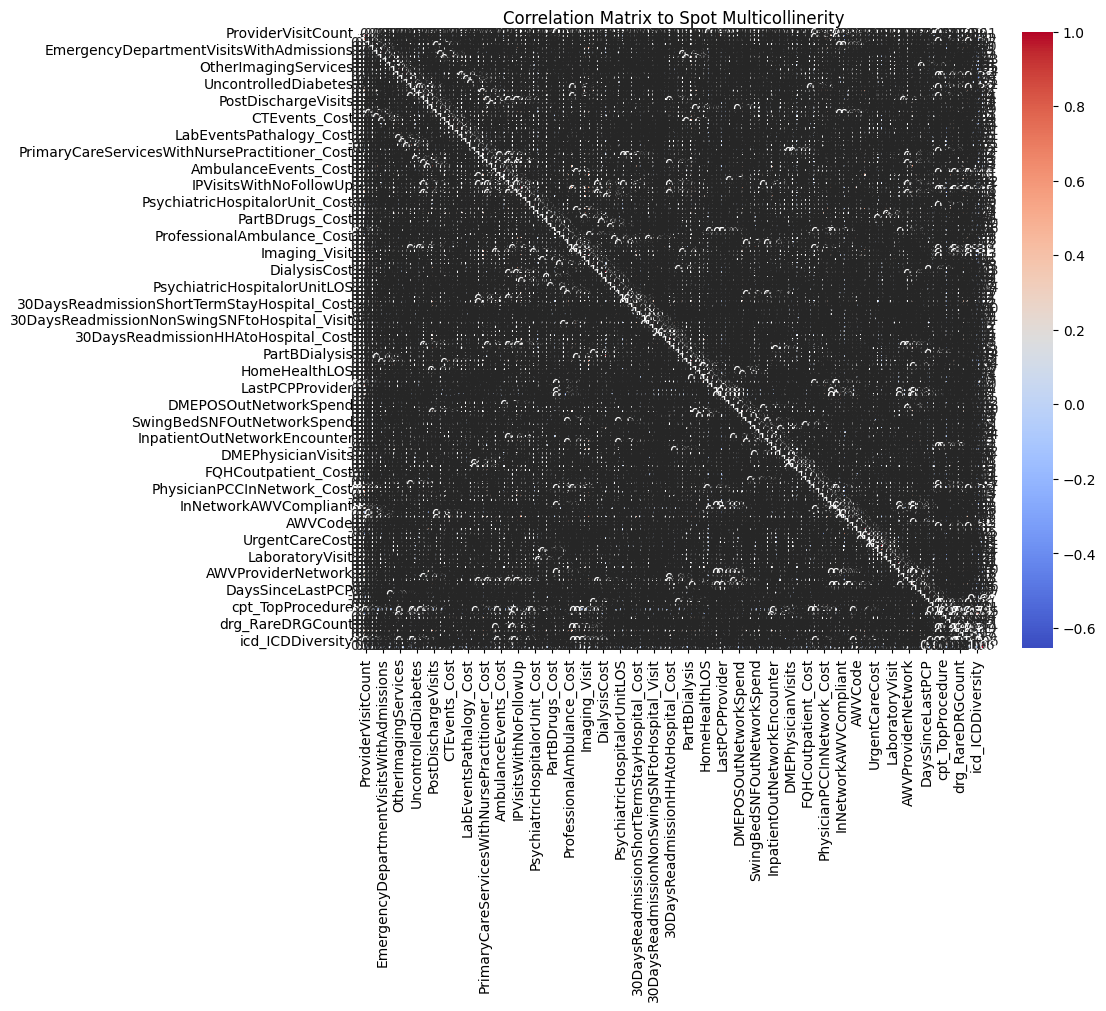

In [29]:
import seaborn as sns

# 1. Compute the correlation matrix
corr_matrix = X_train.select_dtypes(include=['number']).corr()

# 2. Plot it as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix to Spot Multicollinerity")
plt.show()

In [30]:
# 1. Compute the correlation matrix
corr_matrix = X_train.select_dtypes(include=['number']).corr()

# 2. Plot it as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='bam', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix to Spot Multicollinerity")
plt.show()

KeyError: "'bam' is not a known colormap name"

<Figure size 1000x800 with 0 Axes>